<a href="https://colab.research.google.com/github/darim1151/ANTARES_Analysis/blob/main/antares_alerts_analysis_1(pushed_github).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANTARES Alert Broker Analysis

Exploring the [ANTARES](https://antares.noirlab.edu) (Arizona-NOIRLab Temporal Analysis and Response to Events System) alert broker database. ANTARES processes the ZTF alert stream (and will process LSST alerts) by annotating alerts with cross-matched catalog data, computing derived properties, and applying community-built filters that assign **tags** to objects of interest.

This notebook mirrors the structure of a similar analysis done with the [Fink](https://fink-portal.org) broker, adapted to ANTARES's data model:

| Fink Concept | ANTARES Equivalent |
|---|---|
| Classification (e.g. "SN candidate") | **Tag** (e.g. `nuclear_transient`) |
| Individual alert | **Alert** (nested inside a Locus) |
| Unique object (objectId) | **Locus** (aggregated object record) |
| REST API (POST requests) | **`antares_client`** Python library (ElasticSearch queries) |

In [10]:
# ============================================================
# Setup and Imports
# ============================================================
!pip install antares-client elasticsearch-dsl astropy matplotlib pandas numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy.coordinates import SkyCoord, Angle
from antares_client.search import (
    search, cone_search, get_by_id, get_by_ztf_object_id,
    get_available_tags, catalog_search
)
from antares_client.models import Locus
from elasticsearch_dsl import Search as ESSearch
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Setup complete")

Setup complete


## Discover Available Tags

ANTARES filters assign **tags** to loci (objects). These are the equivalent of Fink's classifier labels. Let's see what's available.

In [11]:
tags = get_available_tags()

print("Available ANTARES Tags")
print("=" * 60)
for i, tag in enumerate(sorted(tags), 1):
    print(f"{i:3d}. {tag}")

print(f"\nTotal: {len(tags)} tags")

Available ANTARES Tags
  1. ECL_blue_transient_candidate
  2. LAISS_RFC_AD_filter
  3. NUTTelA_TAO
  4. blue_transient
  5. desi_target
  6. desoto_classified
  7. dimmers
  8. dwarf_nova_outburst
  9. extragalactic
 10. high_amplitude_transient_candidate
 11. high_amplitude_variable_star_candidate
 12. high_flux_ratio_wrt_nn
 13. high_snr
 14. imhb_candidate
 15. in_m31
 16. iso_forest_anomaly_detection
 17. lc_feature_extractor
 18. matheson_extreme_vpdf
 19. nova_test
 20. nuclear_transient
 21. recent_reddening
 22. refitt_newsources_snrcut
 23. siena_mag_coord_cut
 24. soraisam_sublum
 25. sso_candidates
 26. sso_confirmed
 27. superphot_plus_classified
 28. young_extragalactic_candidate

Total: 28 tags


## Retrieve Loci by Tag

We'll query ANTARES for loci matching several scientifically interesting tags. Each query uses ElasticSearch under the hood via the `antares_client`.

**Note:** `search()` returns a lazy iterator. We cap each tag at `MAX_PER_TAG` loci to keep runtime reasonable.

In [3]:
# Tags to retrieve — customized selection
TAGS_TO_RETRIEVE = [
    "young_extragalactic_candidate",
    "sso_confirmed",
    "high_flux_ratio_wrt_nn",
    "extragalactic",
    "high_snr",
    "dwarf_nova_outburst",
    "high_amplitude_variable_star_candidate",
]

MAX_PER_TAG = 10000

def locus_to_record(locus, retrieved_tag):
    """Extract key fields from a Locus into a flat dict for DataFrame construction."""
    return {
        'locus_id': locus.locus_id,
        'ra': locus.ra,
        'dec': locus.dec,
        'num_mag_values': locus.properties.get('num_mag_values', None),
        'newest_alert_observation_time': locus.properties.get('newest_alert_observation_time', None),
        'brightest_alert_magnitude': locus.properties.get('brightest_alert_magnitude', None),
        'ztf_object_id': locus.properties.get('ztf_object_id', None),
        'all_tags': ', '.join(locus.tags) if locus.tags else '',
        'num_catalogs': len(locus.catalogs) if locus.catalogs else 0,
        'retrieved_tag': retrieved_tag,
    }

print(f"Retrieving up to {MAX_PER_TAG} loci for each tag")
print("=" * 60)

all_records = []

for tag in TAGS_TO_RETRIEVE:
    # Check that the tag actually exists before querying
    if tag not in tags:
        print(f"\n  WARNING: '{tag}' not found in available tags, skipping")
        continue

    print(f"\nRetrieving: {tag}...")

    query = (
        ESSearch()
        .filter("term", tags=tag)
        .to_dict()
    )

    count = 0
    try:
        for locus in search(query):
            all_records.append(locus_to_record(locus, tag))
            count += 1
            if count >= MAX_PER_TAG:
                break
        print(f"  Retrieved {count} loci")
    except Exception as e:
        print(f"  Error: {e}")

if all_records:
    df_loci = pd.DataFrame(all_records)
    print(f"\n{'=' * 60}")
    print(f"Total loci retrieved: {len(df_loci)}")
    print(f"Unique loci: {df_loci['locus_id'].nunique()}")
else:
    print("\nNo results found for any tag")
    df_loci = pd.DataFrame()

Retrieving up to 10000 loci for each tag

Retrieving: young_extragalactic_candidate...
  Retrieved 10000 loci

Retrieving: sso_confirmed...
  Retrieved 10000 loci

Retrieving: high_flux_ratio_wrt_nn...
  Retrieved 10000 loci

Retrieving: extragalactic...
  Retrieved 10000 loci

Retrieving: high_snr...
  Retrieved 10000 loci

Retrieving: dwarf_nova_outburst...
  Retrieved 4692 loci

Retrieving: high_amplitude_variable_star_candidate...
  Retrieved 10000 loci

Total loci retrieved: 64692
Unique loci: 55464


### Adjust Tags (if needed)

If the tags above didn't all exist, update `TAGS_TO_RETRIEVE` with valid tags from the list and re-run the cell above. Common ANTARES tags include things like `nuclear_transient`, `extragalactic`, `SN_Ia`, `SN_II`, `AGN`, etc. — the exact set depends on which filters are currently active.

## Basic Statistics

In [4]:
if len(df_loci) > 0:
    print("=" * 60)
    print("LOCUS STATISTICS")
    print("=" * 60)

    print(f"\nTotal loci: {len(df_loci)}")
    print(f"Unique loci: {df_loci['locus_id'].nunique()}")

    print(f"\nLoci by retrieved tag:")
    tag_counts = df_loci['retrieved_tag'].value_counts()
    for tag, count in tag_counts.items():
        print(f"  {tag}: {count}")

    print(f"\nMagnitude summary (brightest alert):")
    mag_col = 'brightest_alert_magnitude'
    if df_loci[mag_col].notna().any():
        print(f"  Min (brightest): {df_loci[mag_col].min():.2f}")
        print(f"  Max (faintest):  {df_loci[mag_col].max():.2f}")
        print(f"  Median:          {df_loci[mag_col].median():.2f}")

    print(f"\nObservation count summary (num_mag_values):")
    obs_col = 'num_mag_values'
    if df_loci[obs_col].notna().any():
        print(f"  Min:    {df_loci[obs_col].min():.0f}")
        print(f"  Max:    {df_loci[obs_col].max():.0f}")
        print(f"  Median: {df_loci[obs_col].median():.0f}")

    print(f"\nCatalog cross-match summary:")
    print(f"  Loci with at least 1 catalog match: {(df_loci['num_catalogs'] > 0).sum()} / {len(df_loci)}")
    print(f"  Average catalogs per locus: {df_loci['num_catalogs'].mean():.1f}")
else:
    print("No data available for statistics")

LOCUS STATISTICS

Total loci: 64692
Unique loci: 55464

Loci by retrieved tag:
  young_extragalactic_candidate: 10000
  sso_confirmed: 10000
  high_flux_ratio_wrt_nn: 10000
  extragalactic: 10000
  high_snr: 10000
  high_amplitude_variable_star_candidate: 10000
  dwarf_nova_outburst: 4692

Magnitude summary (brightest alert):
  Min (brightest): 9.45
  Max (faintest):  20.67
  Median:          16.47

Observation count summary (num_mag_values):
  Min:    1
  Max:    3912
  Median: 210

Catalog cross-match summary:
  Loci with at least 1 catalog match: 53857 / 64692
  Average catalogs per locus: 5.1


## Sky Distribution (Aitoff Projection)

Visualize where the retrieved loci fall on the sky, colored by tag.

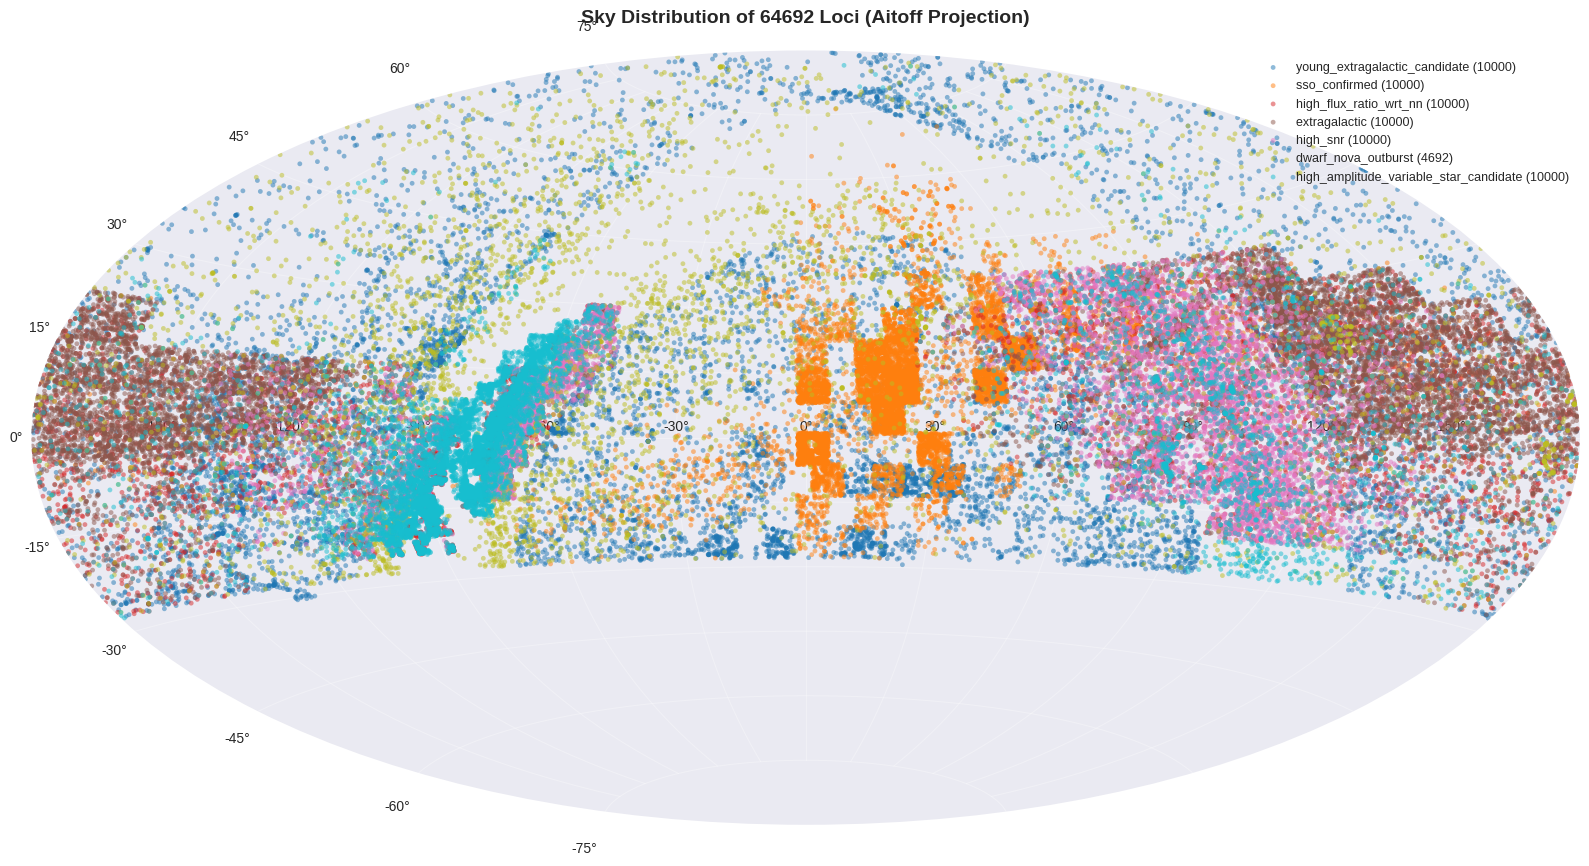


Sky coverage:
  RA range:  0.00° to 360.00°
  Dec range: -30.43° to 88.01°


In [5]:
if len(df_loci) > 0 and df_loci['ra'].notna().any():
    ra_rad = np.radians(df_loci['ra'].values)
    ra_rad = np.where(ra_rad > np.pi, ra_rad - 2 * np.pi, ra_rad)
    dec_rad = np.radians(df_loci['dec'].values)

    fig = plt.figure(figsize=(16, 9))
    ax = fig.add_subplot(111, projection='aitoff')

    tag_names = df_loci['retrieved_tag'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(tag_names)))

    for i, tag in enumerate(tag_names):
        mask = df_loci['retrieved_tag'] == tag
        ax.scatter(
            ra_rad[mask], dec_rad[mask],
            s=12, alpha=0.5, c=[colors[i]],
            label=f"{tag} ({mask.sum()})", edgecolors='none'
        )

    ax.set_title(
        f'Sky Distribution of {len(df_loci)} Loci (Aitoff Projection)',
        fontsize=14, fontweight='bold', pad=20
    )
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
    plt.tight_layout()
    plt.show()

    print(f"\nSky coverage:")
    print(f"  RA range:  {df_loci['ra'].min():.2f}° to {df_loci['ra'].max():.2f}°")
    print(f"  Dec range: {df_loci['dec'].min():.2f}° to {df_loci['dec'].max():.2f}°")
else:
    print("No coordinate data available for sky plot")

## Temporal Distribution of Observations

Convert the `newest_alert_observation_time` (MJD) to calendar dates and plot.

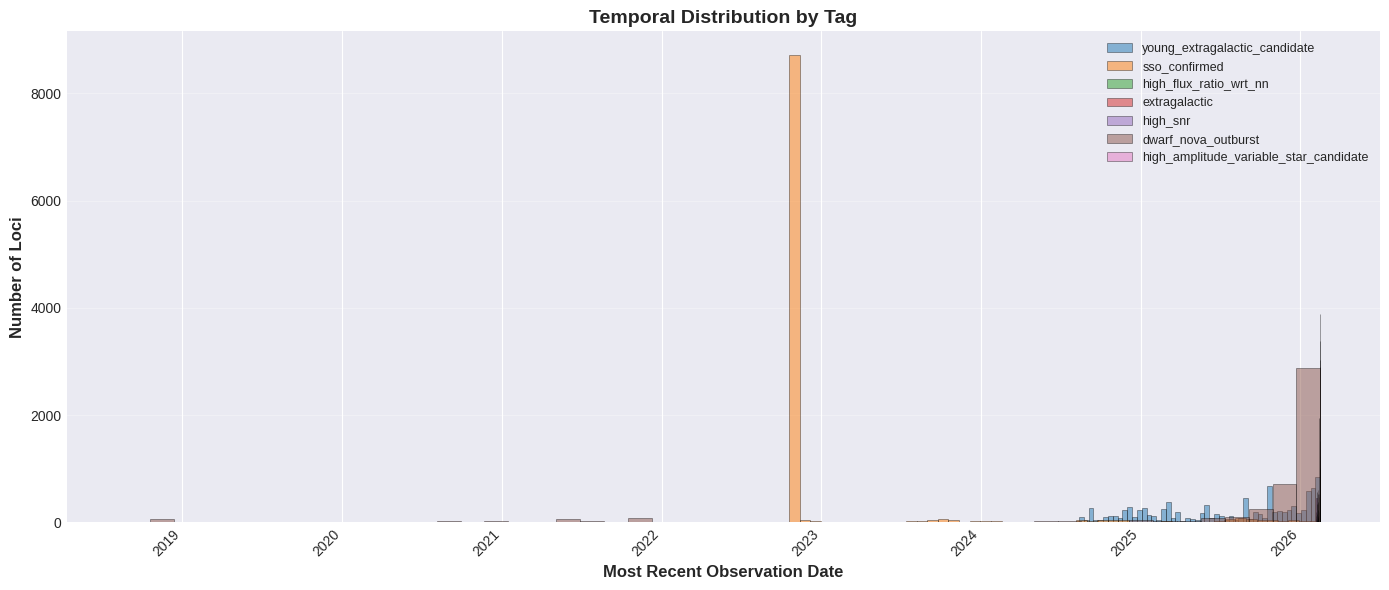


Temporal coverage:
  Earliest observation: 2018-08-25 08:48:12.003840
  Latest observation:   2026-02-15 07:36:13.999661
  Time span: 2730 days (7.5 years)


In [6]:
time_col = 'newest_alert_observation_time'

if len(df_loci) > 0 and df_loci[time_col].notna().any():
    valid = df_loci[df_loci[time_col].notna()].copy()
    times = Time(valid[time_col].values, format='mjd')
    valid['datetime'] = times.datetime

    fig, ax = plt.subplots(figsize=(14, 6))

    for tag in valid['retrieved_tag'].unique():
        mask = valid['retrieved_tag'] == tag
        ax.hist(valid.loc[mask, 'datetime'], bins=50, alpha=0.5,
                label=tag, edgecolor='black', linewidth=0.5)

    ax.set_xlabel('Most Recent Observation Date', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Loci', fontsize=12, fontweight='bold')
    ax.set_title('Temporal Distribution by Tag', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=9, framealpha=0.9)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\nTemporal coverage:")
    print(f"  Earliest observation: {valid['datetime'].min()}")
    print(f"  Latest observation:   {valid['datetime'].max()}")
    span = (valid['datetime'].max() - valid['datetime'].min()).days
    print(f"  Time span: {span} days ({span/365.25:.1f} years)")
else:
    print("No temporal data available")

## Magnitude Distribution

Distribution of the brightest observed magnitude for each locus, split by tag.

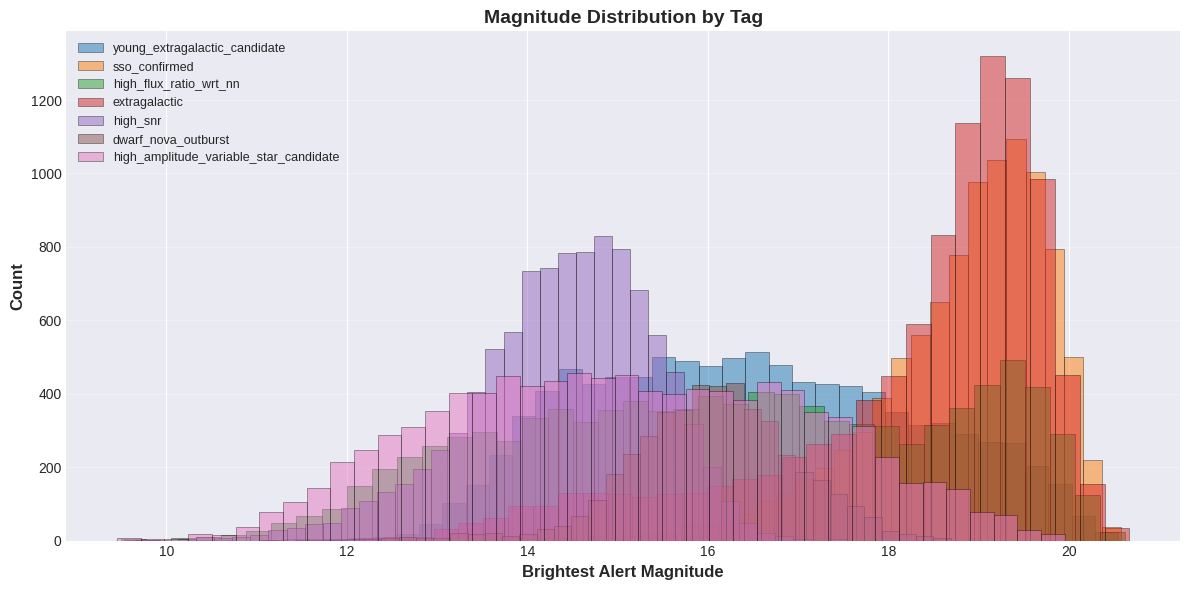

In [7]:
mag_col = 'brightest_alert_magnitude'

if len(df_loci) > 0 and df_loci[mag_col].notna().any():
    valid = df_loci[df_loci[mag_col].notna()]

    fig, ax = plt.subplots(figsize=(12, 6))

    for tag in valid['retrieved_tag'].unique():
        mask = valid['retrieved_tag'] == tag
        ax.hist(valid.loc[mask, mag_col], bins=40, alpha=0.5,
                label=tag, edgecolor='black', linewidth=0.5)

    ax.set_xlabel('Brightest Alert Magnitude', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax.set_title('Magnitude Distribution by Tag', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=9, framealpha=0.9)
    plt.tight_layout()
    plt.show()
else:
    print("No magnitude data available")

## Observation Count Distribution

How many photometric measurements does each locus have? Well-observed loci have richer light curves for classification.

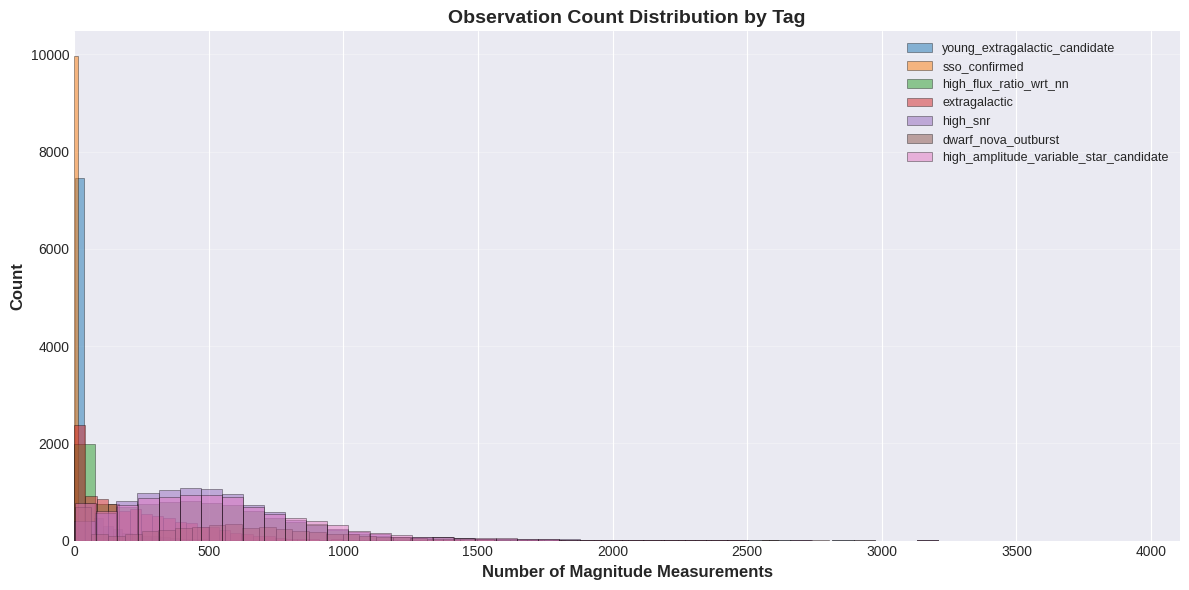

Median observations per tag:
  young_extragalactic_candidate: 7
  sso_confirmed: 1
  high_flux_ratio_wrt_nn: 394
  extragalactic: 174
  high_snr: 479
  dwarf_nova_outburst: 565
  high_amplitude_variable_star_candidate: 490


In [8]:
obs_col = 'num_mag_values'

if len(df_loci) > 0 and df_loci[obs_col].notna().any():
    valid = df_loci[df_loci[obs_col].notna()]

    fig, ax = plt.subplots(figsize=(12, 6))

    for tag in valid['retrieved_tag'].unique():
        mask = valid['retrieved_tag'] == tag
        ax.hist(valid.loc[mask, obs_col], bins=50, alpha=0.5,
                label=tag, edgecolor='black', linewidth=0.5)

    ax.set_xlabel('Number of Magnitude Measurements', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax.set_title('Observation Count Distribution by Tag', fontsize=14, fontweight='bold')
    ax.set_xlim(left=0)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=9, framealpha=0.9)
    plt.tight_layout()
    plt.show()

    print(f"Median observations per tag:")
    for tag in valid['retrieved_tag'].unique():
        med = valid.loc[valid['retrieved_tag'] == tag, obs_col].median()
        print(f"  {tag}: {med:.0f}")
else:
    print("No observation count data available")

## Save Results

In [9]:
if len(df_loci) > 0:
    output_file = 'antares_loci_by_tag.csv'
    df_loci.to_csv(output_file, index=False)
    print(f"Saved {len(df_loci)} loci to {output_file}")

    print(f"\nColumn summary:")
    for col in df_loci.columns:
        non_null = df_loci[col].notna().sum()
        print(f"  {col}: {non_null}/{len(df_loci)} non-null")
else:
    print("No data to save")

Saved 64692 loci to antares_loci_by_tag.csv

Column summary:
  locus_id: 64692/64692 non-null
  ra: 64692/64692 non-null
  dec: 64692/64692 non-null
  num_mag_values: 64692/64692 non-null
  newest_alert_observation_time: 64692/64692 non-null
  brightest_alert_magnitude: 64692/64692 non-null
  ztf_object_id: 64692/64692 non-null
  all_tags: 64692/64692 non-null
  num_catalogs: 64692/64692 non-null
  retrieved_tag: 64692/64692 non-null
